# Aprendizaje no Supervisado

# Librerias

Usamos las librerias correspondientes para el aprendizaje no supervisado, como ejemplo tenemos pandas para leer nuestro dataset y utilizar diferentes formatos para representar nuestro dataset, usamos numpy para los calculos adecuados como para la cuestion de determinar el volumen, matplotlib para las graficas y sklearn para los diferentes algortimos usados en aprendizaje no supervisado como K-Means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

# Configuración de matplotlib
plt.style.use('default')
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# Lectura del Dataset

Leemos y mostramos con pandas el Datset de diferentes tipos de Frijoles que tienen como caracteristicas sus Áreas, Permietros, Longitud de eje Mayor y Menor, Relacion de Aspecto, Excentricidad, Área Convexa, Diametro y demas que nos ayudaran para la identificacion de cada frijol

In [2]:

df = pd.read_csv("Dry_Bean_Dataset.csv")
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


# Elección de método para determinar el volumen

Seleccionamos cual sera el mejor metodo que nos servira para determinar el volumen de un frijol a traves de las correlaciones

In [3]:
df['Volumen_Estimado_1'] = df['Area'] * df['MinorAxisLength'] * 0.5
df['Volumen_Estimado_2'] = (4/3) * np.pi * (df['MajorAxisLength']/2) * (df['MinorAxisLength']/2)**2
df['Volumen_Estimado_3'] = (4/3) * np.pi * (df['EquivDiameter']/2)**3

# Correlación entre métodos y características físicas
correlations = df[['Area', 'MajorAxisLength', 'MinorAxisLength', 
                   'Volumen_Estimado_1', 'Volumen_Estimado_2', 
                   'Volumen_Estimado_3']].corr()

# Ver cuál correlaciona mejor con las dimensiones reales
print("Correlaciones con Area:")
print(f"Método 1: {correlations['Area']['Volumen_Estimado_1']:.3f}")
print(f"Método 2: {correlations['Area']['Volumen_Estimado_2']:.3f}")  
print(f"Método 3: {correlations['Area']['Volumen_Estimado_3']:.3f}")

Correlaciones con Area:
Método 1: 0.981
Método 2: 0.981
Método 3: 0.987


# Selección de características y Estandarización de los datos

In [4]:
# Seleccionar todas las características numéricas excepto 'Class' y los volúmenes estimados 1 y 2
feature_columns = [col for col in df.columns 
                   if col != 'Class' and 
                   col != 'Volumen_Estimado_1' and 
                   col != 'Volumen_Estimado_2' and 
                   df[col].dtype != 'O']

X = df[feature_columns].values

print(f"\n=== PREPARACIÓN PARA CLUSTERING ===")
print(f"Características seleccionadas: {len(feature_columns)}")
print(f"Forma de X: {X.shape}")

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados exitosamente")


=== PREPARACIÓN PARA CLUSTERING ===
Características seleccionadas: 17
Forma de X: (13611, 17)
Datos estandarizados exitosamente


In [5]:
# Seleccionar todas las características numéricas excepto 'Class' y los volúmenes estimados 1 y 2
feature_columns = [col for col in df.columns 
                   if col != 'Class' and 
                   col != 'Volumen_Estimado_1' and 
                   col != 'Volumen_Estimado_2' and 
                   df[col].dtype != 'O']

X = df[feature_columns].values

print(f"\n=== PREPARACIÓN PARA CLUSTERING ===")
print(f"Características seleccionadas: {len(feature_columns)}")
print(f"Forma de X: {X.shape}")

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados exitosamente")


=== PREPARACIÓN PARA CLUSTERING ===
Características seleccionadas: 17
Forma de X: (13611, 17)
Datos estandarizados exitosamente


In [6]:
# Seleccionar todas las características numéricas excepto 'Class' y los volúmenes estimados 1 y 2
feature_columns = [col for col in df.columns 
                   if col != 'Class' and 
                   col != 'Volumen_Estimado_1' and 
                   col != 'Volumen_Estimado_2' and 
                   df[col].dtype != 'O']

X = df[feature_columns].values

print(f"\n=== PREPARACIÓN PARA CLUSTERING ===")
print(f"Características seleccionadas: {len(feature_columns)}")
print(f"Forma de X: {X.shape}")

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados exitosamente")


=== PREPARACIÓN PARA CLUSTERING ===
Características seleccionadas: 17
Forma de X: (13611, 17)
Datos estandarizados exitosamente


In [7]:
# Seleccionar todas las características numéricas excepto 'Class' y los volúmenes estimados 1 y 2
feature_columns = [col for col in df.columns 
                   if col != 'Class' and 
                   col != 'Volumen_Estimado_1' and 
                   col != 'Volumen_Estimado_2' and 
                   df[col].dtype != 'O']

X = df[feature_columns].values

print(f"\n=== PREPARACIÓN PARA CLUSTERING ===")
print(f"Características seleccionadas: {len(feature_columns)}")
print(f"Forma de X: {X.shape}")

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos estandarizados exitosamente")


=== PREPARACIÓN PARA CLUSTERING ===
Características seleccionadas: 17
Forma de X: (13611, 17)
Datos estandarizados exitosamente



=== DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS ===
Calculando K-means para k=2...
Calculando K-means para k=3...
Calculando K-means para k=4...
Calculando K-means para k=5...
Calculando K-means para k=6...
Calculando K-means para k=7...
Calculando K-means para k=8...
Calculando K-means para k=9...
Calculando K-means para k=10...
Calculando K-means para k=11...
Calculando K-means para k=12...
Calculando K-means para k=13...
Calculando K-means para k=14...


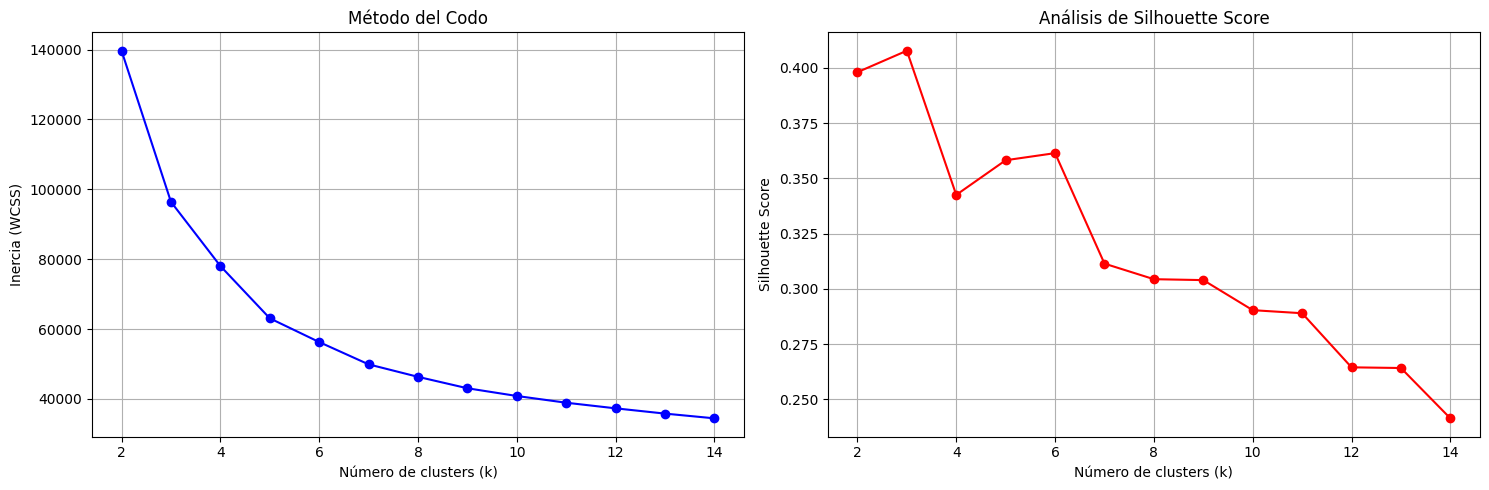

Número óptimo de clusters: 3
Silhouette Score máximo: 0.4078


In [8]:
print(f"\n=== DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS ===")

# Rango de k a evaluar
k_range = range(2, 15)

# Calcular K-means para diferentes valores de k
kmeans_per_k = []
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"Calculando K-means para k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    kmeans_per_k.append(kmeans)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizar métricas de evaluación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Método del codo (Elbow Method)
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Método del Codo')
ax1.grid(True)

# Silhouette Score
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Análisis de Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.savefig('evaluacion_numero_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Encontrar el k óptimo basado en silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
max_silhouette = max(silhouette_scores)

print(f"Número óptimo de clusters: {optimal_k}")
print(f"Silhouette Score máximo: {max_silhouette:.4f}")


=== ANÁLISIS DETALLADO DE SILHOUETTE ===


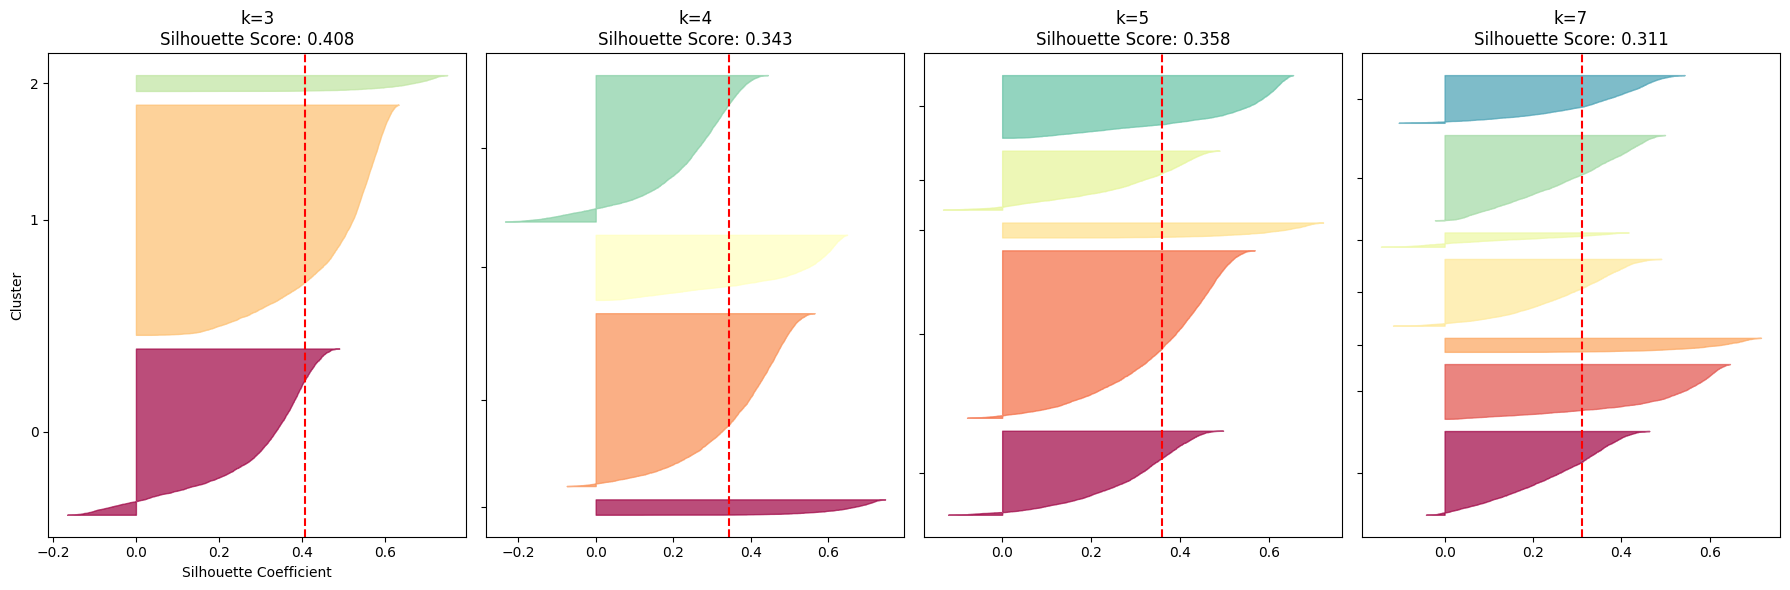

In [9]:
print(f"\n=== ANÁLISIS DETALLADO DE SILHOUETTE ===")

# Seleccionar algunos valores de k para análisis detallado
k_values_detailed = [3, 5, 7, optimal_k, optimal_k+1, optimal_k+2]
k_values_detailed = [k for k in k_values_detailed if k in k_range]
k_values_detailed = sorted(list(set(k_values_detailed)))[:6]  # Máximo 6 para visualización

fig, axes = plt.subplots(1, len(k_values_detailed), figsize=(18, 6))
if len(k_values_detailed) == 1:
    axes = [axes]

for ax, k in zip(axes, k_values_detailed):
    kmeans = kmeans_per_k[list(k_range).index(k)]
    y_pred = kmeans.labels_
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        ax.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))
    ax.set_title(f"k={k}\nSilhouette Score: {silhouette_scores[list(k_range).index(k)]:.3f}", fontsize=12)
    ax.axvline(x=silhouette_scores[list(k_range).index(k)], color="red", linestyle="--")
    
    if k == k_values_detailed[0]:
        ax.set_ylabel("Cluster")
        ax.set_xlabel("Silhouette Coefficient")
    else:
        ax.set_yticklabels([])

plt.tight_layout()
plt.show()


In [10]:
print(f"\n=== APLICACIÓN DEL CLUSTERING ÓPTIMO (k={optimal_k}) ===")

# Aplicar K-means con el k óptimo
best_kmeans = kmeans_per_k[list(k_range).index(optimal_k)]
cluster_labels = best_kmeans.labels_

# Agregar las etiquetas de cluster al dataframe
df['Cluster'] = cluster_labels

print(f"Distribución de clusters:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)


=== APLICACIÓN DEL CLUSTERING ÓPTIMO (k=3) ===
Distribución de clusters:
0    5488
1    7599
2     524
Name: count, dtype: int64



=== VISUALIZACIÓN 2D USANDO PCA ===
Varianza explicada por las 2 primeras componentes: 0.9894
Componente 1: 0.5602
Componente 2: 0.2639


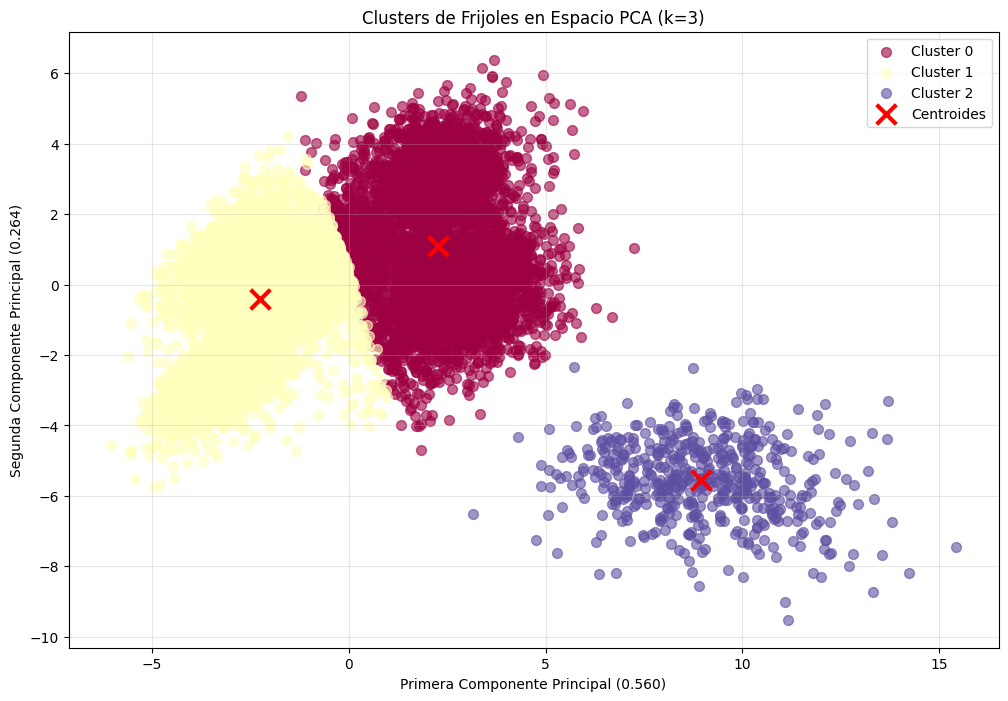

In [11]:
print(f"\n=== VISUALIZACIÓN 2D USANDO PCA ===")

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por las 2 primeras componentes: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Componente 1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Componente 2: {pca.explained_variance_ratio_[1]:.4f}")

# Visualizar clusters en espacio PCA
plt.figure(figsize=(12, 8))
colors = plt.cm.Spectral(np.linspace(0, 1, optimal_k))

# Obtener el modelo KMeans y las etiquetas para el número óptimo de clusters
best_kmeans = kmeans_per_k[list(k_range).index(optimal_k)]
cluster_labels = best_kmeans.labels_

for i in range(optimal_k):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=50)

# Plotear centroides
centroids_pca = pca.transform(best_kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='Centroides')

plt.xlabel(f'Primera Componente Principal ({pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'Segunda Componente Principal ({pca.explained_variance_ratio_[1]:.3f})')
plt.title(f'Clusters de Frijoles en Espacio PCA (k={optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('clusters_pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
print(f"\n=== COMPARACIÓN CON CLASES REALES ===")

# Crear tabla de contingencia
contingency_table = pd.crosstab(df['Class'], df['Cluster'], margins=True)
print("Tabla de contingencia (Clase Real vs Cluster):")
print(contingency_table)

# Calcular pureza de clusters
cluster_purity = []
for cluster_id in range(optimal_k):
    cluster_mask = df['Cluster'] == cluster_id
    cluster_data = df[cluster_mask]
    most_common_class = cluster_data['Class'].mode()[0]
    purity = (cluster_data['Class'] == most_common_class).sum() / len(cluster_data)
    cluster_purity.append(purity)
    print(f"Cluster {cluster_id}: Clase dominante = {most_common_class}, Pureza = {purity:.3f}")

average_purity = np.mean(cluster_purity)
print(f"\nPureza promedio de los clusters: {average_purity:.3f}")


=== COMPARACIÓN CON CLASES REALES ===
Tabla de contingencia (Clase Real vs Cluster):
Cluster      0     1    2    All
Class                           
BARBUNYA  1218   103    1   1322
BOMBAY       0     0  522    522
CALI      1622     7    1   1630
DERMASON    37  3509    0   3546
HOROZ     1909    19    0   1928
SEKER        6  2021    0   2027
SIRA       696  1940    0   2636
All       5488  7599  524  13611
Cluster 0: Clase dominante = HOROZ, Pureza = 0.348
Cluster 1: Clase dominante = DERMASON, Pureza = 0.462
Cluster 2: Clase dominante = BOMBAY, Pureza = 0.996

Pureza promedio de los clusters: 0.602
